In [ ]:
!pip install nnunetv2

In [1]:
import os
import sys
import json
import numpy as np
import nibabel as nib
import yaml
import subprocess
import kagglehub

from pathlib import Path
from google.colab import drive, files

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/Временно/archive.zip

In [ ]:
files.upload()

In [8]:
%%bash
nohup python my_long_running_script.py > output.log 2>&1 &
echo "Started"

Started


In [4]:
os.environ["nnUNet_raw"] = "/content/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/content/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/content/nnUNet_results"

In [5]:
# 1. Plan & Preprocess
!nnUNetv2_plan_and_preprocess -d 001 -pl nnUNetPlannerResEncM --verify_dataset_integrity

Fingerprint extraction...
Dataset001_Sen2Fire
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
100% 1962/1962 [00:56<00:00, 34.99it/s]
Experiment planning...
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 13, 'patch_size': (np.int64(512), np.int64(512)), 'median_image_size_in_voxels': array([512., 512.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalizat

In [ ]:
!ps aux | grep python | grep my_long_running_script.py
# !kill 187071

In [10]:
# 2. Train
!nnUNetv2_train 001 2d 0 -p nnUNetResEncUNetMPlans --npz

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-11-21 05:03:14.669441: Using torch.compile...
2025-11-21 05:03:18.163372: do_dummy_2d_data_aug: False
2025-11-21 05:03:18.168047: Using splits from existing split file: /content/nnUNet_preprocessed/Dataset001_Sen2Fire/splits_final.json
2025-11-21 05:03:18.168374: The split file contains 1 splits.
2025-11-21 05:03:18.168438: Desired fold for training: 0
2025-11-21 05:03:18.168480: This split has 1458 training and 504 validation cases.
using pin_memory on device 0
/usr/local/lib/python3.12/dist-packages/fft_conv_pytorch/fft_conv.py:139: UserWarning: Using a non-tuple

In [ ]:
# Продолжить обучение с checkpoint (флаг --c)
!nnUNetv2_train 001 2d 0 -p nnUNetResEncUNetMPlans --npz --c

In [11]:
# 3. Predict
!nnUNetv2_predict \
  -d 001 \
  -i /content/nnUNet_raw/Dataset001_Sen2Fire/imagesTs \
  -o /content/nnUNet_results/Dataset001_Sen2Fire/pred_2d \
  -c 2d \
  -p nnUNetResEncUNetMPlans \
  -f 0 \
  -chk checkpoint_best.pth \
  --save_probabilities


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 504 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 504 cases that I would like to predict

Predicting Sen2Fire_1962:
perform_everything_on_device: True
100% 1/1 [00:00<00:00,  1.01it/s]
sending off prediction to background worker for resampling and export
done with Sen2Fire_1962

Predicting Sen2Fire_1963:
perform_everything_on_device: True
100% 1/1 [00:00<00:00, 10.67it/s]
sending off prediction to background worker for resampling and export
done with Sen2Fire_1963

Predicting Sen2Fire_1964:
perform_everything_on_de

In [12]:
# inference
!nnUNetv2_evaluate_folder \
  /content/nnUNet_raw/Dataset001_Sen2Fire/labelsTs \
  /content/nnUNet_results/Dataset001_Sen2Fire/pred_2d \
  -djfile /content/nnUNet_results/Dataset001_Sen2Fire/pred_2d/dataset.json \
  -pfile /content/nnUNet_results/Dataset001_Sen2Fire/pred_2d/plans.json

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer


In [13]:
!cat /content/nnUNet_results/Dataset001_Sen2Fire/pred_2d/summary.json | jq | head -n 50

{
  "foreground_mean": {
    "Dice": 0.12429760832774064,
    "FN": 10705.140873015873,
    "FP": 7058.371031746032,
    "IoU": 0.08676656833497398,
    "TN": 239941.42460317462,
    "TP": 4439.063492063492,
    "n_pred": 11497.434523809523,
    "n_ref": 15144.204365079366
  },
  "mean": {
    "1": {
      "Dice": 0.12429760832774064,
      "FN": 10705.140873015873,
      "FP": 7058.371031746032,
      "IoU": 0.08676656833497398,
      "TN": 239941.42460317462,
      "TP": 4439.063492063492,
      "n_pred": 11497.434523809523,
      "n_ref": 15144.204365079366
    }
  },
  "metric_per_case": [
    {
      "metrics": {
        "1": {
          "Dice": null,
          "FN": 0,
          "FP": 0,
          "IoU": null,
          "TN": 262144,
          "TP": 0,
          "n_pred": 0,
          "n_ref": 0
        }
      },
      "prediction_file": "/content/nnUNet_results/Dataset001_Sen2Fire/pred_2d/Sen2Fire_1962.nii.gz",
      "reference_file": "/content/nnUNet_raw/Dataset001_Sen2Fire/la

In [ ]:
# zip
!nnUNetv2_export_model_to_zip \
    -d 001 \
    -o /content/model_2d_sen2fire_best.zip \
    -c 2d \
    -p nnUNetResEncUNetMPlans \
    -f 0 \
    -chk checkpoint_best.pth

In [15]:
files.download("/content/model_2d_sen2fire_best.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

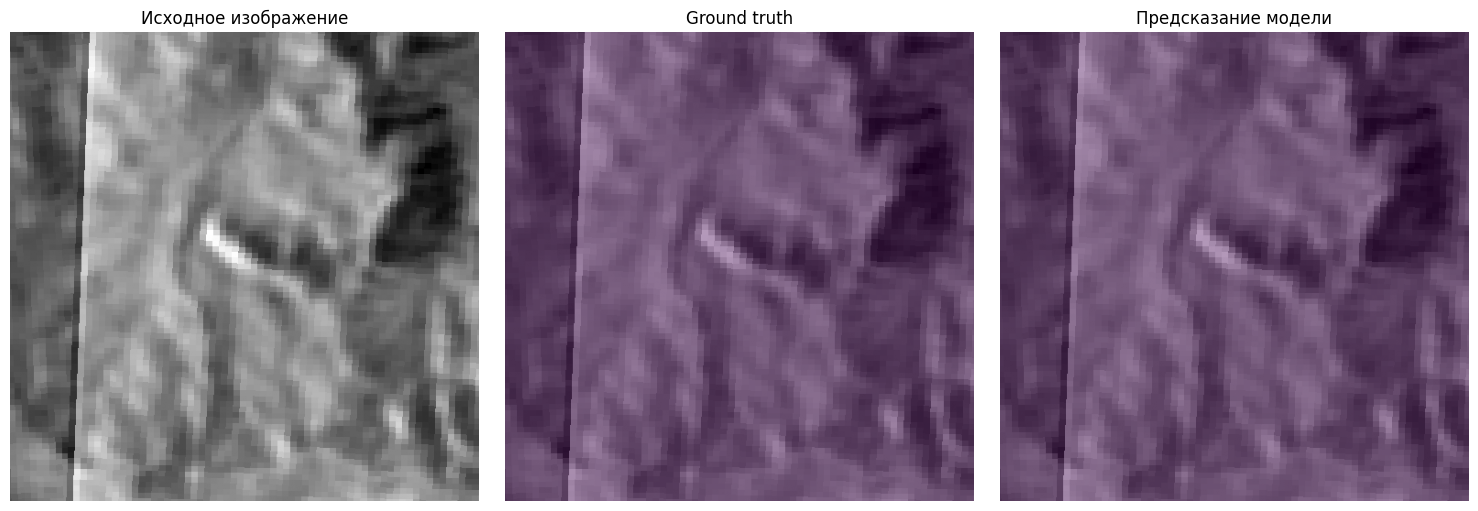

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --- настройки ---
case_id = "Sen2Fire_1962"

img_path = f"/content/nnUNet_raw/Dataset001_Sen2Fire/imagesTs/{case_id}_0000.nii.gz"
gt_path  = f"/content/nnUNet_raw/Dataset001_Sen2Fire/labelsTs/{case_id}.nii.gz"
pred_path = f"/content/nnUNet_results/Dataset001_Sen2Fire/pred_2d/{case_id}.nii.gz"

# --- загрузка ---
img_nii = nib.load(img_path)
gt_nii = nib.load(gt_path)
pred_nii = nib.load(pred_path)

img = img_nii.get_fdata()
gt = gt_nii.get_fdata()
pred = pred_nii.get_fdata()

# На всякий случай «выжмем» до 2D (если там есть лишние оси)
img2d = np.squeeze(img)
gt2d = np.squeeze(gt)
pred2d = np.squeeze(pred)

# Нормализуем картинку для отображения
img_norm = img2d.astype(float)
img_norm = img_norm - img_norm.min()
if img_norm.max() > 0:
    img_norm = img_norm / img_norm.max()

# --- рисуем ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Исходное изображение")
plt.imshow(img_norm, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Ground truth")
plt.imshow(img_norm, cmap="gray")
plt.imshow(gt2d, alpha=0.4)  # полупрозрачная GT маска
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Предсказание модели")
plt.imshow(img_norm, cmap="gray")
plt.imshow(pred2d, alpha=0.4)  # полупрозрачная предсказанная маска
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Проверка с изменением трегхолда
# Как наложить эту маску??
import numpy as np

prob = np.load("/content/nnUNet_results/Dataset001_Sen2Fire/pred_2d/Sen2Fire_1962.npz")["probabilities"]
mask = prob.argmax(0)  # nnU-Net использует это